# Analyse Exploratoire

### Import des modules

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('2016_Building_Energy_Benchmarking.csv')
TARGET = 'SiteEnergyUse(kBtu)'



### Analyse Exploratoire

--- 1. DIAGNOSTIC DES DONNÉES MANQUANTES ---
La colonne SecondLargestPropertyUseType est vide à 48.8%
La colonne SecondLargestPropertyUseTypeGFA est vide à 48.8%
La colonne ThirdLargestPropertyUseType est vide à 79.7%
La colonne ThirdLargestPropertyUseTypeGFA est vide à 79.7%
La colonne YearsENERGYSTARCertified est vide à 93.8%
La colonne Comments est vide à 100.0%
La colonne Outlier est vide à 99.0%

--- 2. BILAN DU NETTOYAGE ---
Nombre de bâtiments au départ : 3376
Nombre après retrait du résidentiel : 1558
Bâtiments incohérents supprimés (Surface ou Conso <= 0) : 16
Nombre final de bâtiments conservés : 1542


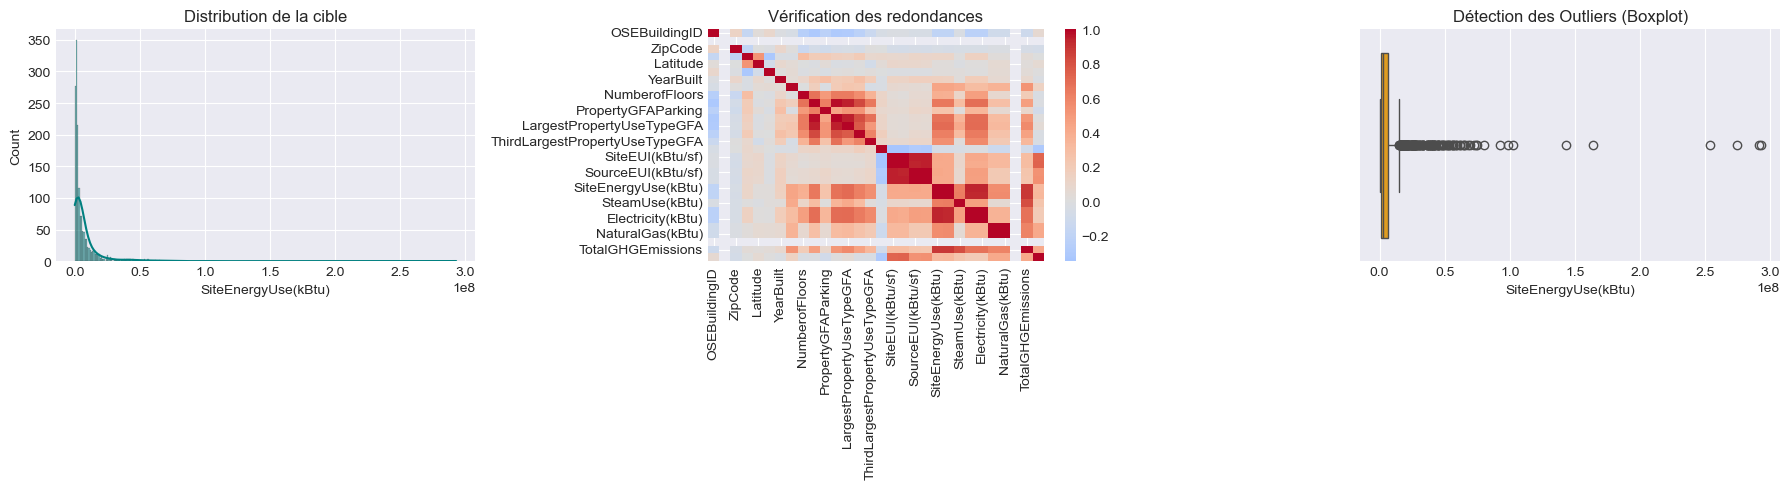


--- TERMINER L'ANALYSE : Action réussie. ---
Variable créée : df_filtered (1542 lignes).
JUSTIFICATION TECHNIQUE :
1. Le filtrage élimine les types de bâtiments hors périmètre (résidentiel).
2. La suppression des valeurs <= 0 garantit la cohérence physique.
3. La présence d'outliers (boxplot) justifie l'utilisation future de modèles robustes ou de transformation Log.


In [6]:
# =================================================================
# 2. Analyse Exploratoire : Constatations & Nettoyage Final
# =================================================================

# 1. ÉTAPE DE FILTRAGE MÉTIER
# On crée df_filtered en ne gardant que le non-résidentiel 
nb_initial = len(df)
df_filtered = df[df['BuildingType'].str.contains('NonResidential|Non-Residential|SPS-District K-12', na=False)]

# 2. DIAGNOSTIC DES DONNÉES MANQUANTES
cols_vides = ['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 
              'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 
              'YearsENERGYSTARCertified', 'Comments', 'Outlier']

print("--- 1. DIAGNOSTIC DES DONNÉES MANQUANTES ---")
for col in cols_vides:
    if col in df_filtered.columns:
        taux_vide = df_filtered[col].isna().mean() * 100
        print(f"La colonne {col} est vide à {taux_vide:.1f}%")

# 3. NETTOYAGE PHYSIQUE (Valeurs incohérentes)
mask_incoherent = (df_filtered['PropertyGFATotal'] <= 0) | (df_filtered['SiteEnergyUse(kBtu)'] <= 0)
incoherents = df_filtered[mask_incoherent]
df_filtered = df_filtered[~mask_incoherent]

print(f"\n--- 2. BILAN DU NETTOYAGE ---")
print(f"Nombre de bâtiments au départ : {nb_initial}")
print(f"Nombre après retrait du résidentiel : {len(df_filtered) + len(incoherents)}")
print(f"Bâtiments incohérents supprimés (Surface ou Conso <= 0) : {len(incoherents)}")
print(f"Nombre final de bâtiments conservés : {len(df_filtered)}")

# 4. VISUALISATIONS 
plt.figure(figsize=(18, 5))

# A. Distribution de la cible (Après nettoyage)
plt.subplot(1, 3, 1)
sns.histplot(df_filtered['SiteEnergyUse(kBtu)'], kde=True, color='teal')
plt.title('Distribution de la cible')

# B. Matrice de corrélation (Détection Redondances)
plt.subplot(1, 3, 2)
numeric_cols = df_filtered.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Vérification des redondances')

# C. Détection des Outliers (Justification IQR)
plt.subplot(1, 3, 3)
sns.boxplot(x=df_filtered['SiteEnergyUse(kBtu)'], color='orange')
plt.title('Détection des Outliers (Boxplot)')

plt.tight_layout()
plt.show()

# 5. CONCLUSION DE L'ANALYSE
print("\n--- TERMINER L'ANALYSE : Action réussie. ---")
print(f"Variable créée : df_filtered ({len(df_filtered)} lignes).")
print("JUSTIFICATION TECHNIQUE :")
print("1. Le filtrage élimine les types de bâtiments hors périmètre (résidentiel).")
print("2. La suppression des valeurs <= 0 garantit la cohérence physique.")
print("3. La présence d'outliers (boxplot) justifie l'utilisation future de modèles robustes ou de transformation Log.")


#### TERMINER L'ANALYSE EXPLORATOIRE 

In [7]:
# =================================================================
# 3. TERMINER L'ANALYSE EXPLORATOIRE : Synthèse & Target
# =================================================================

# 1. Définition de la Target (Cible)
# On fixe la variable cible une fois pour toutes pour la suite
TARGET = 'SiteEnergyUse(kBtu)'

# 2. Transformation Logarithmique (Justifiée par le Boxplot précédent)
# Les modèles de régression performent mieux sur une cible symétrique
df_filtered['SiteEnergyUse_Log'] = np.log1p(df_filtered[TARGET])

# 3. Bilan final avant Modélisation
print(f"--- RÉSUMÉ DU DATASET PRÊT ---")
print(f"Nombre de bâtiments : {df_filtered.shape[0]}")
print(f"Nombre de variables initiales : {df_filtered.shape[1]}")
print(f"Moyenne de consommation : {df_filtered[TARGET].mean():.2f} kBtu")

print("\n Analyse exploratoire clôturée. Prêt pour le Feature Engineering.")


--- RÉSUMÉ DU DATASET PRÊT ---
Nombre de bâtiments : 1542
Nombre de variables initiales : 47
Moyenne de consommation : 7530317.29 kBtu

 Analyse exploratoire clôturée. Prêt pour le Feature Engineering.


A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

# Modélisation 

### Import des modules 

### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [8]:
# =================================================================
# 5. FEATURE ENGINEERING : Création des variables
# =================================================================

# A. TEMPORALITÉ : Âge du bâtiment
# Justification : L'ancienneté influe sur l'isolation et l'efficacité des systèmes.
df_filtered['BuildingAge'] = 2016 - df_filtered['YearBuilt']

# B. STRUCTURE : Surface moyenne par étage
# Justification : Permet de distinguer la forme du bâtiment (étalé vs tour).
df_filtered['NumberofFloors'] = df_filtered['NumberofFloors'].replace(0, 1)
df_filtered['GFA_per_Floor'] = df_filtered['PropertyGFATotal'] / df_filtered['NumberofFloors']

# C. USAGES MULTIPLES : 
# Justification : Indique si le bâtiment doit gérer plusieurs types d'activités.
df_filtered['Is_MultiUse'] = df_filtered['SecondLargestPropertyUseTypeGFA'].apply(lambda x: 1 if x > 0 else 0)

# D. SOURCES D'ÉNERGIE : (Information structurelle SANS Data Leakage)
# Justification : On indique l'équipement (Gaz) sans donner la consommation réelle.
df_filtered['Has_Gas'] = (df_filtered['NaturalGas(kBtu)'] > 0).astype(int)

# E. LOCALISATION : Compression de la cardinalité 
# Justification : Réduit le nombre de colonnes créées par le OneHotEncoder.
top_10_neigh = df_filtered['Neighborhood'].value_counts().nlargest(10).index
df_filtered['Neighborhood_Clean'] = df_filtered['Neighborhood'].apply(lambda x: x if x in top_10_neigh else 'Other')

print(" Étape Feature Engineering terminée avec succès.")


 Étape Feature Engineering terminée avec succès.


### Préparation des features pour la modélisation

In [9]:
# =================================================================
# 6. PRÉPARATION DES FEATURES ET DU PREPROCESSOR
# =================================================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- ÉTAPE CRUCIALE : Suppression des NaNs dans la cible ---
# On ne garde que les lignes où la consommation est connue
df_model = df_filtered.dropna(subset=['SiteEnergyUse_Log']).copy()

# 1. Sélection finale des colonnes
features_num = ['PropertyGFATotal', 'NumberofBuildings', 'NumberofFloors', 
                'BuildingAge', 'GFA_per_Floor']
features_cat = ['PrimaryPropertyType', 'Neighborhood_Clean', 'Is_MultiUse', 'Has_Gas']

X = df_model[features_num + features_cat]
y = df_model['SiteEnergyUse_Log']

# 2. Création de X_train et X_test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. CRÉATION DU PREPROCESSOR
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), features_num),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), features_cat)
])

print(f" Préparation terminée après suppression des NaNs en cible.")
print(f"Nombre de bâtiments valides pour le modèle : {len(df_model)}")
print(f"Le jeu d'entraînement contient {X_train.shape[0]} bâtiments.")

 Préparation terminée après suppression des NaNs en cible.
Nombre de bâtiments valides pour le modèle : 1540
Le jeu d'entraînement contient 1232 bâtiments.


A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

### Comparaison de différents modèles supervisés

In [10]:
# =================================================================
# 7. COMPARAISON DES MODÈLES (Régression Linéaire, Random Forest, SVM)
# =================================================================
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Définition des modèles dans un dictionnaire
models = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest (Base)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "SVM (SVR)": SVR(kernel='rbf', C=100, gamma=0.1)
}

# 2. Initialisation de l'affichage
print(f"{'Modèle':<25} | {'R2 Score':<10} | {'MAE (kBtu)':<12} | {'RMSE (kBtu)':<12}")
print("-" * 75)

results_r2 = {}
results_mae = {}

# 3. Boucle d'entraînement et d'évaluation
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('algo', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)
    
    # --- CALCUL DES MÉTRIQUES ---
    r2 = r2_score(y_test, y_pred_log)
    
    # Conversion en unités RÉELLES
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    # Stockage
    results_r2[name] = r2
    results_mae[name] = mae
    
    print(f"{name:<25} | {r2:<10.4f} | {mae:<12,.0f} | {rmse:<12,.0f}")

# 4. Identification du meilleur modèle
best_model_name = max(results_r2, key=results_r2.get)
mae_to_beat = results_mae[best_model_name]

print("-" * 75)
print(f" Modèle élu pour l'optimisation : {best_model_name}")
print(f" Erreur à battre (MAE) : {mae_to_beat:,.0f} kBtu")

Modèle                    | R2 Score   | MAE (kBtu)   | RMSE (kBtu) 
---------------------------------------------------------------------------
Régression Linéaire       | 0.4584     | 73,449,737   | 882,983,280 
Random Forest (Base)      | 0.6958     | 3,045,258    | 7,856,712   
SVM (SVR)                 | 0.5162     | 3,943,924    | 9,824,737   
---------------------------------------------------------------------------
 Modèle élu pour l'optimisation : Random Forest (Base)
 Erreur à battre (MAE) : 3,045,258 kBtu


A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [11]:
# =================================================================
# 8. OPTIMISATION ET INTERPRÉTATION DU MODÈLE 12 combinaisons
# =================================================================
from sklearn.model_selection import GridSearchCV

# 1. On repart du pipeline avec le meilleur modèle identifié (Random Forest)
pipe_opt = Pipeline([
    ('prep', preprocessor),
    ('algo', RandomForestRegressor(random_state=42))
])

# 2. DÉFINITION DE LA PETITE GRILLE (Test de 12 combinaisons)
# 2 (n_est) * 3 (depth) * 2 (split) = 12 combinaisons
param_grid_test = {
    'algo__n_estimators': [50, 100],
    'algo__max_depth': [5, 10, 15],
    'algo__min_samples_split': [5, 10]
}

print(f" Lancement du test d'optimisation (12 combinaisons)..." )
print(f" Objectif : Battre la MAE de {mae_to_beat:,.0f} kBtu")

# 3. GridSearchCV
# cv=5 : chaque combinaison sera testée 5 fois (60 fits au total)
grid_search_test = GridSearchCV(
    pipe_opt, 
    param_grid_test, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

grid_search_test.fit(X_train, y_train)

# 4. EXTRACTION DU MEILLEUR MODÈLE DE TEST
best_pipe_test = grid_search_test.best_estimator_
y_pred_test = best_pipe_test.predict(X_test)

# 5. CALCUL DU GAIN DE TEST
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

mae_test = mean_absolute_error(y_test_real, y_pred_real)
gain_test = mae_to_beat - mae_test

print("\n" + "="*45)
print("--- RÉSULTATS DU TEST D'OPTIMISATION ---")
print(f"Meilleurs paramètres (Test) : {grid_search_test.best_params_}")
print(f"MAE obtenue : {mae_test:,.0f} kBtu")
print(f" Gain provisoire : {gain_test:,.0f} kBtu")
print("="*45)

if gain_test > 0:
    print(" Le code fonctionne et l'optimisation améliore le modèle.")
else:
    print(" Gain nul ou négatif : la grille de test est trop simple ou le modèle de base était déjà optimal.")

 Lancement du test d'optimisation (12 combinaisons)...
 Objectif : Battre la MAE de 3,045,258 kBtu
Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- RÉSULTATS DU TEST D'OPTIMISATION ---
Meilleurs paramètres (Test) : {'algo__max_depth': 15, 'algo__min_samples_split': 10, 'algo__n_estimators': 100}
MAE obtenue : 3,003,960 kBtu
 Gain provisoire : 41,298 kBtu
 Le code fonctionne et l'optimisation améliore le modèle.


 Lancement de la Grid Search à grande échelle (108 combinaisons)...
Nombre total de fits : 540
Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- RÉSULTATS DÉFINITIFS ---
Meilleurs paramètres : {'algo__bootstrap': True, 'algo__max_depth': 20, 'algo__min_samples_leaf': 1, 'algo__min_samples_split': 10, 'algo__n_estimators': 300}
R² Final   : 0.6953
MAE Finale : 3,017,423 kBtu
 GAIN TOTAL : 27,835 kBtu


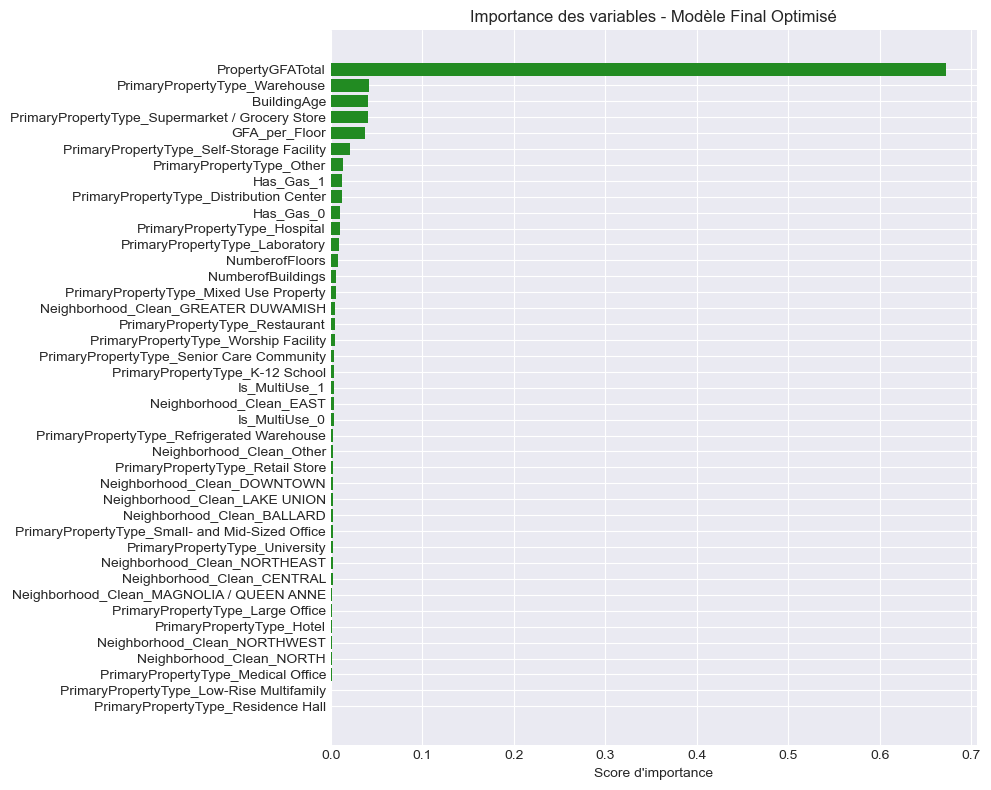

In [12]:
# =================================================================
# 8. OPTIMISATION FINALE (GRANDE ÉCHELLE)
# =================================================================

# 1. Définition de la grille large (108 combinaisons)
# On explore le bootstrap et des profondeurs plus fines
param_grid_large = {
    'algo__n_estimators': [100, 200, 300],
    'algo__max_depth': [12, 15, 20],
    'algo__min_samples_split': [2, 5, 10],
    'algo__min_samples_leaf': [1, 2],
    'algo__bootstrap': [True, False]
}

print(f" Lancement de la Grid Search à grande échelle (108 combinaisons)...")
print(f"Nombre total de fits : {108 * 5}")

grid_search_final = GridSearchCV(
    pipe_opt, 
    param_grid_large, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

grid_search_final.fit(X_train, y_train)

# 2. RÉSULTATS FINAUX
best_pipe = grid_search_final.best_estimator_
y_pred_final = best_pipe.predict(X_test)

# Conversion et métriques
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_final)

mae_final = mean_absolute_error(y_test_real, y_pred_real)
rmse_final = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_final = r2_score(y_test, y_pred_final)
gain_final = mae_to_beat - mae_final

print("\n" + "="*50)
print("--- RÉSULTATS DÉFINITIFS ---")
print(f"Meilleurs paramètres : {grid_search_final.best_params_}")
print(f"R² Final   : {r2_final:.4f}")
print(f"MAE Finale : {mae_final:,.0f} kBtu")
print(f" GAIN TOTAL : {gain_final:,.0f} kBtu")
print("="*50)

# 3. REPRESENTATION DE LA FEATURE IMPORTANCE 
cat_features = best_pipe.named_steps['prep'].named_transformers_['cat']\
               .named_steps['encoder'].get_feature_names_out(features_cat)
all_features_names = features_num + list(cat_features)

importances = best_pipe.named_steps['algo'].feature_importances_
df_importance = pd.DataFrame({'Feature': all_features_names, 'Importance': importances})\
                  .sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='forestgreen')
plt.title('Importance des variables - Modèle Final Optimisé')
plt.xlabel('Score d\'importance')
plt.tight_layout()
plt.show()

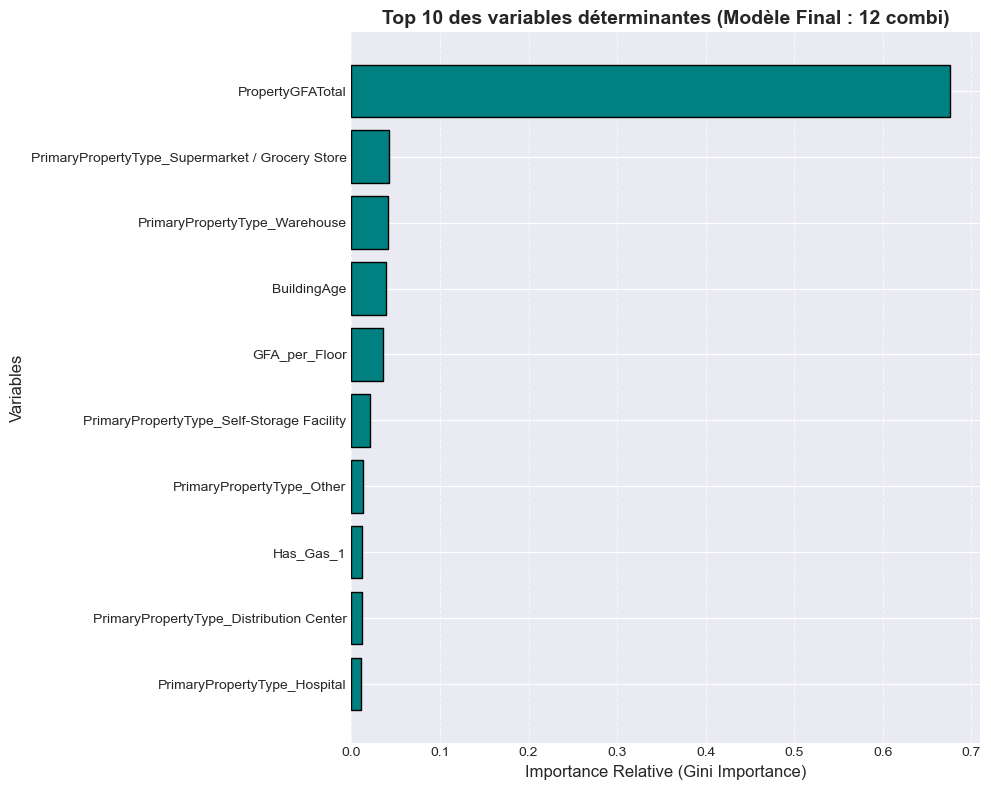


--- CLASSEMENT DES 10 VARIABLES CLÉS ---
                                        Feature  Importance
                               PropertyGFATotal    0.676007
PrimaryPropertyType_Supermarket / Grocery Store    0.042431
                  PrimaryPropertyType_Warehouse    0.041616
                                    BuildingAge    0.039142
                                  GFA_per_Floor    0.035752
      PrimaryPropertyType_Self-Storage Facility    0.021401
                      PrimaryPropertyType_Other    0.013333
                                      Has_Gas_1    0.012469
        PrimaryPropertyType_Distribution Center    0.011761
                   PrimaryPropertyType_Hospital    0.010542


In [13]:
# ==============================================================================
# 9. ANALYSE FINALE : FEATURE IMPORTANCE (MODÈLE OPTIMAL 12 COMBI)
# ==============================================================================

# On utilise l'objet grid_search_test (celui qui a donné le meilleur gain MAE)
best_pipeline = grid_search_test.best_estimator_
best_rf = best_pipeline.named_steps['algo']

# 1. EXTRACTION DYNAMIQUE DES NOMS DE COLONNES
# On récupère le transformer 'cat' par son nom pour éviter les erreurs d'index
cat_transformer = best_pipeline.named_steps['prep'].named_transformers_['cat']
ohe_features = list(cat_transformer.named_steps['encoder'].get_feature_names_out(features_cat))

# Liste complète des features (Numériques + Catégorielles encodées)
all_features_names = features_num + ohe_features

# 2. CRÉATION DU DATAFRAME D'IMPORTANCE
importances_df = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 3. AFFICHAGE GRAPHIQUE (Top 10)
plt.figure(figsize=(10, 8))
plt.barh(importances_df['Feature'].tail(10), 
         importances_df['Importance'].tail(10), 
         color='teal', 
         edgecolor='black')

plt.title('Top 10 des variables déterminantes (Modèle Final : 12 combi)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Relative (Gini Importance)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. AFFICHAGE TEXTUEL POUR LE RAPPORT
print("\n--- CLASSEMENT DES 10 VARIABLES CLÉS ---")
print(importances_df.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

In [18]:
# ==============================================================================
# 10. SAUVEGARDE BENTOML
# ==============================================================================
import bentoml

# Sauvegarde directe
bentoml.sklearn.save_model(
    "seattle_energy_model",
    best_pipeline, 
    custom_objects={
        "columns": all_features_names
    }
)

print("SUCCÈS : Le modèle est sauvegardé.")

SUCCÈS : Le modèle est sauvegardé.
